# Thermal load forecasting (DAH temperature + rolling Ridge, Chronos-Bolt benchmark)

This notebook:

- Loads **actual** outdoor temperature and **thermal load** from `plant1.csv`.
- Loads **day-ahead** 15 min temperature from Open-Meteo (`temperature_forecast_day_ahead_open_meteo_Turnhout_15min.csv`) and compares it to actuals.
- Builds a **rolling Ridge** forecast of `thermal_load` using:
  - **Measured actuals up to the current step** (thermal load history, lag features).
  - **DAH forecast temperature** for the target time (and for the full 24 h horizon ahead), not future actual outdoor temperature.
- Evaluates a **96-step (24 h) horizon** without foresight: at each origin \(t_0\), predictions for \(t_0,\ldots,t_0+95\) use only lags that are **strictly before** \(t_0\) or known calendar time; for a **lag-96** feature at \(t_0+h\), note \(t_0+h-96 \in [t_0-96, t_0-1]\), so **same-time-yesterday** is always already observed when forecasting from \(t_0\) (no recursion needed for that feature).
- Runs a **Chronos-Bolt** zero-shot univariate benchmark on `thermal_load` (no exogenous temperature in the model).
- Exports a CSV for MPC-style use under `output/forecast/`.

## Part 1 – Data input and preparation

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

DATA_DIR = Path("../data")
OUTPUT_DIR = Path("../output/forecast")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PLANT_PATH = DATA_DIR / "plant1.csv"
TEMP_FC_PATH = DATA_DIR / "temperature_forecast_day_ahead_open_meteo_Turnhout_15min.csv"

FORECAST_EXPORT_PATH = OUTPUT_DIR / "forecast_thermal_load_rolling_horizon.csv"


def parse_to_brussels(ts_series: pd.Series) -> pd.Series:
    """Europe/Brussels local time, timezone-aware (unique through DST).

    Parse via UTC then convert to local; do not merge on naive local timestamps.
    """
    ts = pd.to_datetime(ts_series, utc=True, errors="coerce")
    return ts.dt.tz_convert("Europe/Brussels")


plant = pd.read_csv(PLANT_PATH)
plant["timestamp"] = parse_to_brussels(plant["timestamp"])
plant.sort_values("timestamp", inplace=True)
plant = plant.reset_index(drop=True)

for col in ("thermal_load", "outdoor_temperature"):
    plant[col] = pd.to_numeric(plant[col], errors="coerce")

temp_fc = pd.read_csv(TEMP_FC_PATH)
temp_col = [c for c in temp_fc.columns if c != "timestamp"][0]
temp_fc = temp_fc.rename(columns={temp_col: "temp_forecast_dah"})
temp_fc["temp_forecast_dah"] = pd.to_numeric(temp_fc["temp_forecast_dah"], errors="coerce")
temp_fc["timestamp"] = parse_to_brussels(temp_fc["timestamp"])
temp_fc.sort_values("timestamp", inplace=True)
temp_fc = temp_fc.reset_index(drop=True)

# Merge on tz-aware local time (unique). Naive local duplicates keys on DST fall-back.
df = plant[["timestamp", "thermal_load", "outdoor_temperature"]].merge(
    temp_fc[["timestamp", "temp_forecast_dah"]], on="timestamp", how="inner"
)

print(f"Rows: {len(df)} (plant {len(plant)}, temp_fc {len(temp_fc)}) — should match plant length")
print(f"Range: {df['timestamp'].min()} -> {df['timestamp'].max()}")

df.head()

Rows: 35040 (plant 35040, temp_fc 35040) — should match plant length
Range: 2025-01-01 00:00:00+01:00 -> 2025-12-31 23:45:00+01:00


,timestamp,thermal_load,outdoor_temperature,temp_forecast_dah
0,2025-01-01 00:00:00+01:00,91.313867,7.58,5.8
1,2025-01-01 00:15:00+01:00,91.313867,7.58,5.8
2,2025-01-01 00:30:00+01:00,91.313867,7.58,5.8
3,2025-01-01 00:45:00+01:00,91.313867,7.58,5.8
4,2025-01-01 01:00:00+01:00,90.201640,7.78,6.4


## Part 2 – Actual vs day-ahead forecast outdoor temperature

DAH temp vs actual — MAE: 1.211 °C, RMSE: 1.613 °C, bias (fc−actual): 0.232 °C


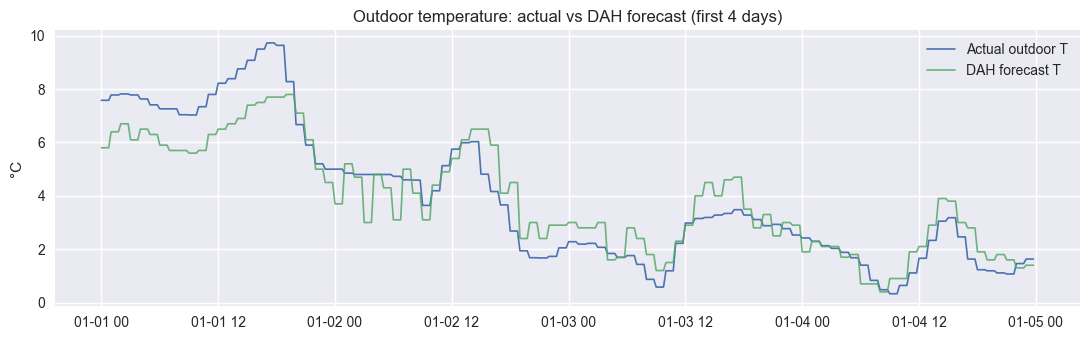

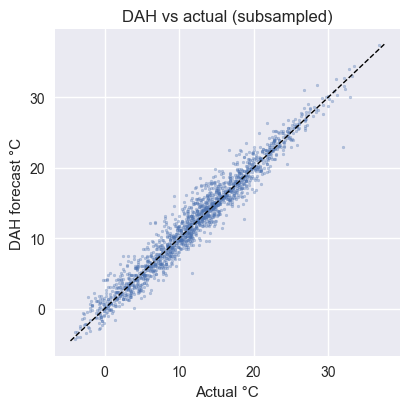

In [2]:
actual_t = df["outdoor_temperature"].to_numpy(dtype=float)
fc_t = df["temp_forecast_dah"].to_numpy(dtype=float)
err = fc_t - actual_t

mae = float(np.nanmean(np.abs(err)))
rmse = float(np.sqrt(np.nanmean(err**2)))
bias = float(np.nanmean(err))
print(f"DAH temp vs actual — MAE: {mae:.3f} °C, RMSE: {rmse:.3f} °C, bias (fc−actual): {bias:.3f} °C")

fig, ax = plt.subplots(figsize=(11, 3.5))
sl = slice(0, 96 * 4)
ax.plot(df["timestamp"].iloc[sl], actual_t[sl], label="Actual outdoor T", lw=1.2)
ax.plot(df["timestamp"].iloc[sl], fc_t[sl], label="DAH forecast T", lw=1.2, alpha=0.85)
ax.set_ylabel("°C")
ax.legend()
ax.set_title("Outdoor temperature: actual vs DAH forecast (first 4 days)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(4.2, 4.2))
ax.scatter(actual_t[::20], fc_t[::20], s=4, alpha=0.35)
lims = np.nanpercentile(np.r_[actual_t, fc_t], [0, 100])
ax.plot([lims[0], lims[1]], [lims[0], lims[1]], "k--", lw=1)
ax.set_xlabel("Actual °C")
ax.set_ylabel("DAH forecast °C")
ax.set_title("DAH vs actual (subsampled)")
plt.tight_layout()
plt.show()

## Part 3 – Rolling Ridge thermal load (DAH exogenous, no future actuals)

**Information policy (aligned with MPC):**

- When predicting the value for an interval, we use **actual thermal load** only from **strictly earlier** intervals (via lag-96 and the training window ending at \(t_0-1\) for an origin \(t_0\)).
- We use **DAH forecast temperature** `temp_forecast_dah` for the **target** time index, not future measured outdoor temperature.

**Training:** rolling window of `TRAIN_STEPS` rows ending at \(t_0-1\). **Refit** every `REFIT_EVERY` steps to limit runtime.

**Features for row \(t\)):** `[temp_forecast_dah[t], thermal_load[t-96], sin/cos hour]`. Weekday harmonics are **omitted**: the plant runs **24/7** with heating to a **fixed** setpoint, so there is no meaningful weekly schedule effect in thermal demand.

For a **96-step horizon from origin \(t_0\)**, the lag-96 regressor at \(t_0+h\) equals `thermal_load[t0+h-96]`, which lies in \([t_0-96, t_0-1]\) — always **observed** before \(t_0\). So horizon forecasts are **direct** (no autoregressive recursion for this feature set).

Daily-refit(last-2-days) Ridge (15-min): MAE=6.223, RMSE=11.148, bias=-0.494


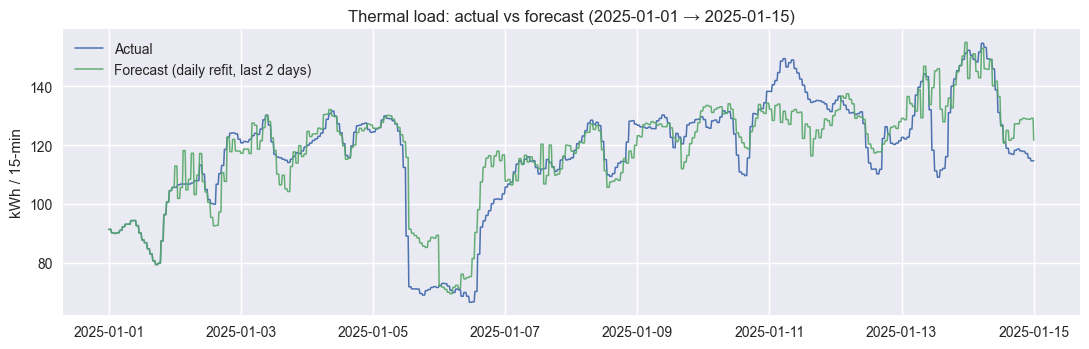

Daily totals: MAE= 411.30415606830775 RMSE= 860.8824515877658


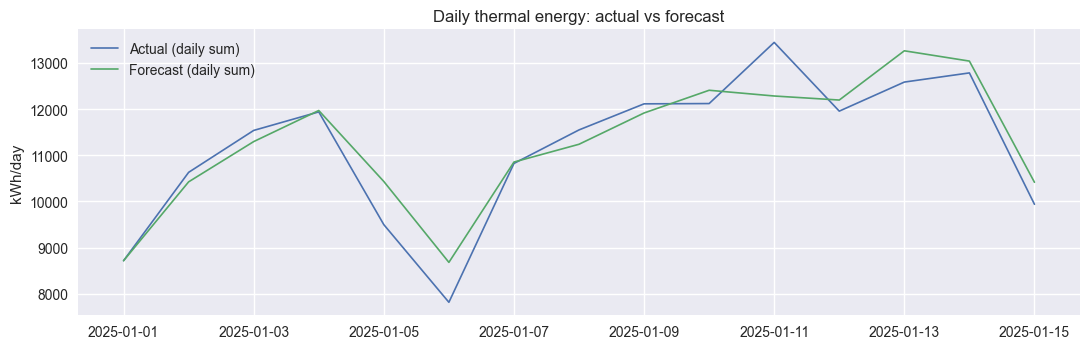

Weekly totals: MAE= 1161.3042782016298 RMSE= 2388.0698146463164


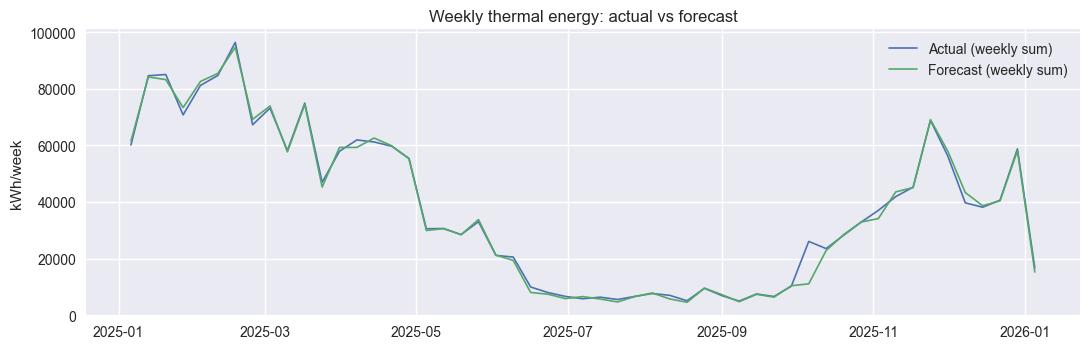

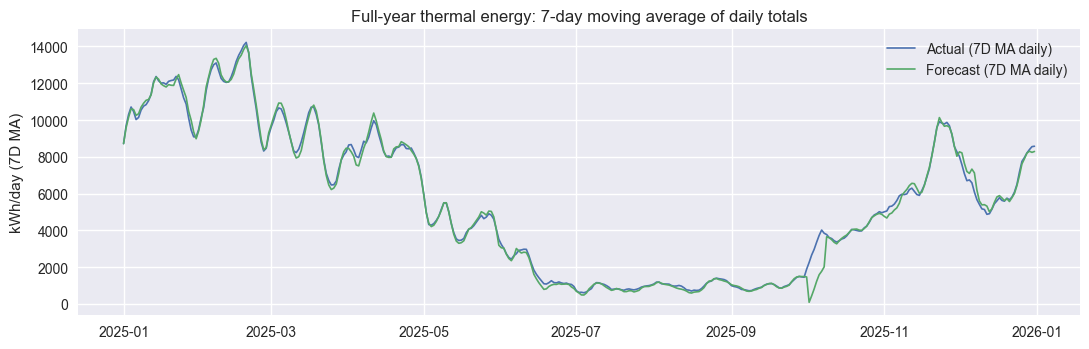

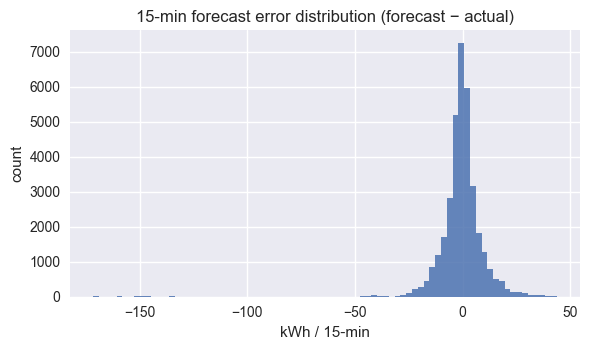

In [3]:
# ----------------------------
# Part 3 – Full-year 35040x1 forecast with DAILY refit (train on last 2 days), then freeze for next day
# Model: Ridge on [temp_forecast_dah[t], thermal_load[t-96]]
#
# For each day D:
#   - Fit coef_D using ONLY days D-2 and D-1 (192 points; if not available, fall back)
#   - Forecast all 96 steps of day D using coef_D
#
# Output: df["thermal_load_forecast_daily_refit_last2days"]
# ----------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

# === Config ===
LAG = 96
RIDGE_ALPHA = 2.0

# Bootstrap first day (since y[t-96] doesn't exist for t<96)
BOOTSTRAP_FIRST_DAY = True
BOOTSTRAP_SEED = 42
BOOT_LAG_NOISE_FRAC = 0.03
BOOT_FC_NOISE_FRAC = 0.02
BOOT_AR = 0.90

# Plot controls (edit these)
PLOT_START = "2025-01-01"
PLOT_END = "2025-01-15"

# === Inputs expected from Part 1 ===
# df columns: ["timestamp"(tz-aware Europe/Brussels), "thermal_load", "temp_forecast_dah", ...]
y = df["thermal_load"].to_numpy(dtype=float)
t_dah = df["temp_forecast_dah"].to_numpy(dtype=float)
ts = pd.DatetimeIndex(df["timestamp"])
n = len(df)

# === Ridge helpers ===
def ridge_fit(X: np.ndarray, y_tr: np.ndarray, alpha: float) -> np.ndarray:
    Xb = np.column_stack([np.ones(len(y_tr)), X])
    p = Xb.shape[1]
    reg = alpha * np.eye(p)
    reg[0, 0] = 0.0
    return np.linalg.solve(Xb.T @ Xb + reg, Xb.T @ y_tr)

def ridge_predict(X: np.ndarray, coef: np.ndarray) -> np.ndarray:
    Xb = np.column_stack([np.ones(len(X)), X])
    return Xb @ coef

def mae(a, b):
    m = np.isfinite(a) & np.isfinite(b)
    return float(np.mean(np.abs(a[m] - b[m])))

def rmse(a, b):
    m = np.isfinite(a) & np.isfinite(b)
    return float(np.sqrt(np.mean((a[m] - b[m]) ** 2)))

# === Lag feature ===
lag96 = np.roll(y, LAG)
lag96[:LAG] = np.nan

# Bootstrap lag96 for first day so day 0 can be forecasted
day0 = slice(0, 96)
if BOOTSTRAP_FIRST_DAY:
    rng = np.random.default_rng(BOOTSTRAP_SEED)
    day0_std = float(np.nanstd(y[day0]))
    if not np.isfinite(day0_std) or day0_std == 0:
        day0_std = float(np.nanstd(y[np.isfinite(y)]))

    eps_lag = rng.normal(0.0, BOOT_LAG_NOISE_FRAC * day0_std, size=96)
    for i in range(1, 96):
        eps_lag[i] = BOOT_AR * eps_lag[i - 1] + (1 - BOOT_AR) * eps_lag[i]
    lag96[day0] = y[day0] + eps_lag

def build_X(idx: np.ndarray) -> np.ndarray:
    return np.column_stack([t_dah[idx], lag96[idx]])

# === Daily refit (last 2 days), then freeze for next day ===
pred = np.full(n, np.nan)

num_days = n // 96
assert num_days * 96 == n, f"Expected full days (n multiple of 96), got n={n}"

for d in range(num_days):
    day_start = d * 96
    day_end = day_start + 96
    day_idx = np.arange(day_start, day_end)

    # Train on last 2 full days available before this day
    if d >= 2:
        train_idx = np.arange((d - 2) * 96, d * 96)  # days d-2 and d-1
    elif d == 1:
        train_idx = np.arange(0, 2 * 96)             # days 0 and 1
    else:  # d == 0
        train_idx = np.arange(0, 96)                 # day 0 only

    X_tr = build_X(train_idx)
    y_tr = y[train_idx]
    mask = ~np.isnan(X_tr).any(axis=1) & np.isfinite(y_tr)

    if mask.sum() < 10:
        continue

    coef = ridge_fit(X_tr[mask], y_tr[mask], RIDGE_ALPHA)

    X_day = build_X(day_idx)
    ok = ~np.isnan(X_day).any(axis=1)
    pred[day_idx[ok]] = ridge_predict(X_day[ok], coef)

# Add small “forecast error” to first day only (optional)
if BOOTSTRAP_FIRST_DAY:
    rng = np.random.default_rng(BOOTSTRAP_SEED + 1)
    day0_std = float(np.nanstd(y[day0]))
    if not np.isfinite(day0_std) or day0_std == 0:
        day0_std = float(np.nanstd(y[np.isfinite(y)]))

    eps_fc = rng.normal(0.0, BOOT_FC_NOISE_FRAC * day0_std, size=96)
    for i in range(1, 96):
        eps_fc[i] = BOOT_AR * eps_fc[i - 1] + (1 - BOOT_AR) * eps_fc[i]
    pred[day0] = pred[day0] + eps_fc

df["thermal_load_forecast_daily_refit_last2days"] = pred

# === Error metrics (15-min) ===
overall_mae = mae(y, pred)
overall_rmse = rmse(y, pred)
bias = float(np.nanmean((pred - y)[np.isfinite(pred) & np.isfinite(y)]))
print(f"Daily-refit(last-2-days) Ridge (15-min): MAE={overall_mae:.3f}, RMSE={overall_rmse:.3f}, bias={bias:.3f}")

# === Plot range mask ===
plot_mask = (df["timestamp"] >= pd.Timestamp(PLOT_START, tz="Europe/Brussels")) & (
    df["timestamp"] <= pd.Timestamp(PLOT_END, tz="Europe/Brussels")
)
dff = df.loc[plot_mask].copy()

# 1) 15-min profile
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(dff["timestamp"], dff["thermal_load"], label="Actual", lw=1.1)
ax.plot(
    dff["timestamp"],
    dff["thermal_load_forecast_daily_refit_last2days"],
    label="Forecast (daily refit, last 2 days)",
    lw=1.1,
    alpha=0.9,
)
ax.set_title(f"Thermal load: actual vs forecast ({PLOT_START} → {PLOT_END})")
ax.set_ylabel("kWh / 15-min")
ax.legend()
plt.tight_layout()
plt.show()

# 2) Daily totals
df_day = (
    df.set_index("timestamp")[["thermal_load", "thermal_load_forecast_daily_refit_last2days"]]
    .resample("D")
    .sum()
)
daily_err = (df_day["thermal_load_forecast_daily_refit_last2days"] - df_day["thermal_load"]).to_numpy()
print("Daily totals: MAE=", float(np.mean(np.abs(daily_err))), "RMSE=", float(np.sqrt(np.mean(daily_err**2))))

fig, ax = plt.subplots(figsize=(11, 3.6))
sl_day = df_day.loc[PLOT_START:PLOT_END]
ax.plot(sl_day.index, sl_day["thermal_load"], label="Actual (daily sum)", lw=1.2)
ax.plot(sl_day.index, sl_day["thermal_load_forecast_daily_refit_last2days"], label="Forecast (daily sum)", lw=1.2)
ax.set_title("Daily thermal energy: actual vs forecast")
ax.set_ylabel("kWh/day")
ax.legend()
plt.tight_layout()
plt.show()

# 3) Weekly totals
df_wk = (
    df.set_index("timestamp")[["thermal_load", "thermal_load_forecast_daily_refit_last2days"]]
    .resample("W-MON")
    .sum()
)
wk_err = (df_wk["thermal_load_forecast_daily_refit_last2days"] - df_wk["thermal_load"]).to_numpy()
print("Weekly totals: MAE=", float(np.mean(np.abs(wk_err))), "RMSE=", float(np.sqrt(np.mean(wk_err**2))))

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(df_wk.index, df_wk["thermal_load"], label="Actual (weekly sum)", lw=1.2)
ax.plot(df_wk.index, df_wk["thermal_load_forecast_daily_refit_last2days"], label="Forecast (weekly sum)", lw=1.2)
ax.set_title("Weekly thermal energy: actual vs forecast")
ax.set_ylabel("kWh/week")
ax.legend()
plt.tight_layout()
plt.show()

# 4) Full-year view (7-day MA of daily totals)
df_day_roll = df_day.rolling(7, min_periods=1).mean()
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(df_day_roll.index, df_day_roll["thermal_load"], label="Actual (7D MA daily)", lw=1.2)
ax.plot(df_day_roll.index, df_day_roll["thermal_load_forecast_daily_refit_last2days"], label="Forecast (7D MA daily)", lw=1.2)
ax.set_title("Full-year thermal energy: 7-day moving average of daily totals")
ax.set_ylabel("kWh/day (7D MA)")
ax.legend()
plt.tight_layout()
plt.show()

# 5) Error distribution (15-min)
e15 = (df["thermal_load_forecast_daily_refit_last2days"] - df["thermal_load"]).to_numpy()
e15 = e15[np.isfinite(e15)]
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.hist(e15, bins=80, alpha=0.85)
ax.set_title("15-min forecast error distribution (forecast − actual)")
ax.set_xlabel("kWh / 15-min")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

## Part 4 – Chronos-Bolt (univariate `thermal_load`)

Chronos-Bolt is **univariate** here: context = past measured `thermal_load` only. It does **not** use DAH temperature inside the model. Use as a **zero-shot benchmark** against the Ridge + DAH model.

Device: cpu


`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!


Chronos-2 model_prediction_length = 1024
Chronos-2 quantiles = [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.99]
Chronos-2 (15-min, mean): MAE=7.010, RMSE=10.980, bias=-0.754


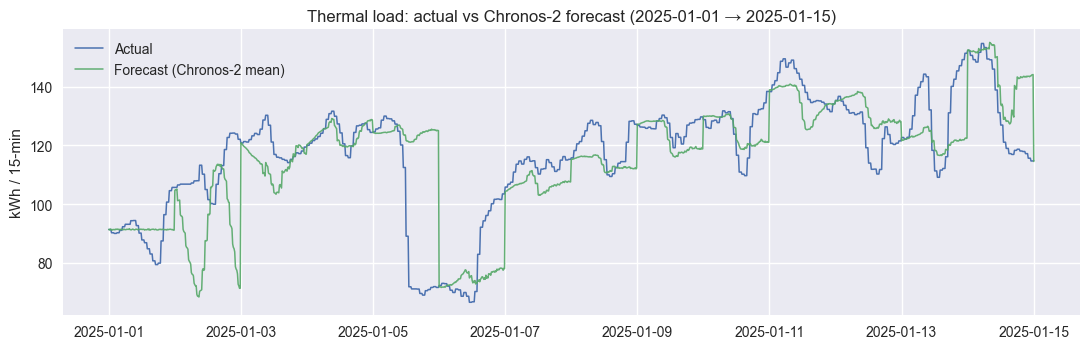

Daily totals: MAE= 506.80490471572847 RMSE= 764.8823097871788


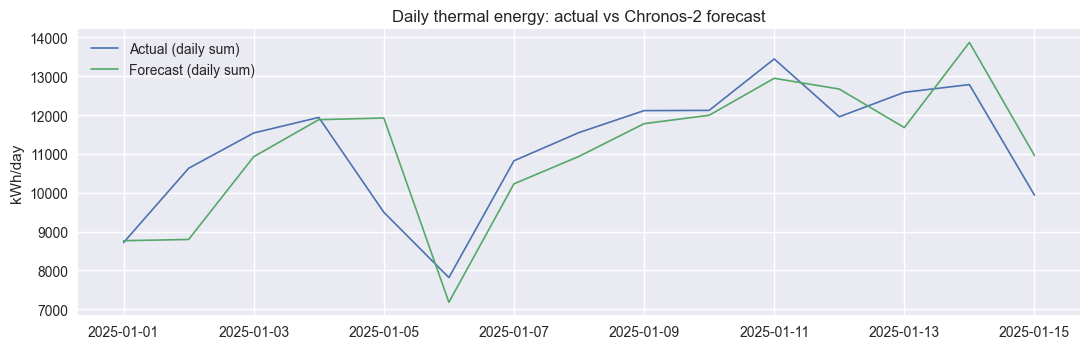

Weekly totals: MAE= 1204.7845979093577 RMSE= 1810.646748671291


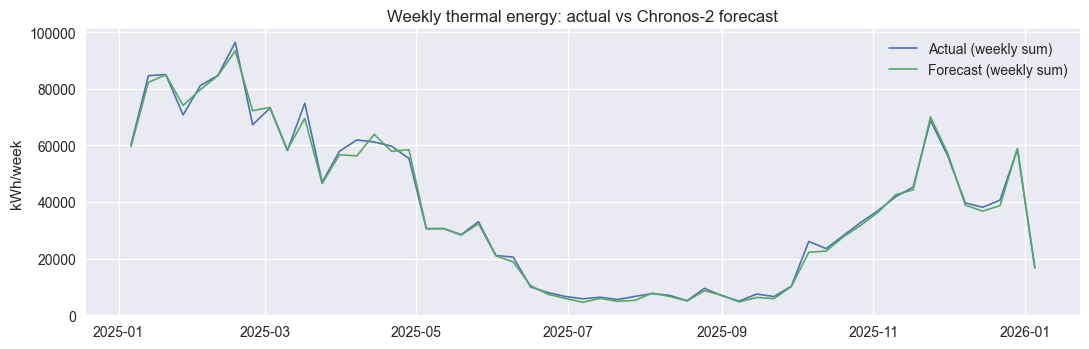

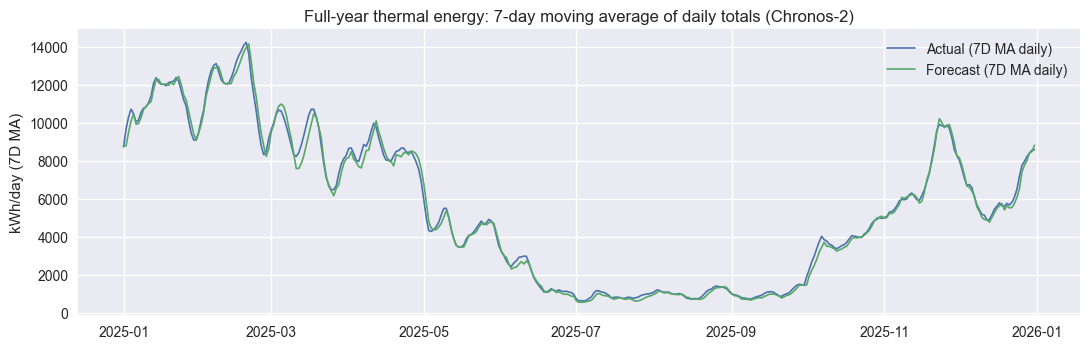

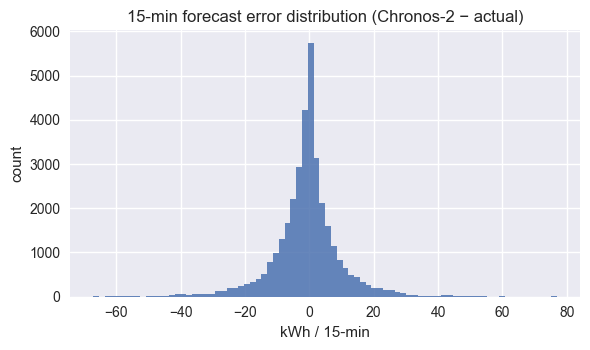

In [4]:
# ----------------------------
# Part 4 – Full-year Chronos-2 forecast (35040x1) with DAILY inference
# FIXED: Chronos-2 requires tensor inputs shaped (n_series, n_variates, history_length)
# so we pass ctx as (1, 1, L) instead of (L,)
#
# Output: df["thermal_load_forecast_chronos2"]
# ----------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from chronos import Chronos2Pipeline

plt.style.use("seaborn-v0_8")

# === Config ===
MODEL_ID = "amazon/chronos-2"
H = 96                 # 24h at 15-min
CONTEXT_LEN = 2048     # truncate history to this many steps

# Plot controls (edit these)
PLOT_START = "2025-01-01"
PLOT_END = "2025-01-15"

# === Inputs expected from Part 1 ===
y = df["thermal_load"].to_numpy(dtype=float)
ts = pd.DatetimeIndex(df["timestamp"])
n = len(df)

num_days = n // 96
assert num_days * 96 == n, f"Expected full days (n multiple of 96), got n={n}"

# === Metrics helpers ===
def _mask(a, b):
    return np.isfinite(a) & np.isfinite(b)

def mae(a, b):
    m = _mask(a, b)
    return float(np.mean(np.abs(a[m] - b[m])))

def rmse(a, b):
    m = _mask(a, b)
    return float(np.sqrt(np.mean((a[m] - b[m]) ** 2)))

# === Load Chronos-2 ===
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

pipe = Chronos2Pipeline.from_pretrained(MODEL_ID, torch_dtype=torch.float32)
if device == "cuda":
    pipe.model = pipe.model.to("cuda")

print("Chronos-2 model_prediction_length =", pipe.model_prediction_length)
print("Chronos-2 quantiles =", pipe.quantiles)

# ----------------------------
# Build full-year 35040x1 forecast, day by day
# ----------------------------
pred = np.full(n, np.nan)

# Day 0 fallback (no history): persistence + small noise
rng = np.random.default_rng(42)
day0 = slice(0, 96)
base0 = float(y[0]) if np.isfinite(y[0]) else float(np.nanmedian(y[np.isfinite(y)]))
std0 = float(np.nanstd(y[day0]))
if not np.isfinite(std0) or std0 == 0:
    std0 = float(np.nanstd(y[np.isfinite(y)]))
pred[day0] = base0 + rng.normal(0.0, 0.02 * std0, size=96)

for d in range(1, num_days):
    day_start = d * 96
    day_end = day_start + 96
    day_idx = np.arange(day_start, day_end)

    # context ends at day_start-1
    ctx_start = max(0, day_start - CONTEXT_LEN)
    ctx = y[ctx_start:day_start]
    ctx = ctx[np.isfinite(ctx)]

    if len(ctx) < 32:
        last = float(y[day_start - 1]) if np.isfinite(y[day_start - 1]) else base0
        pred[day_idx] = last
        continue

    # FIX: shape (1, 1, history_length)
    ctx_t = torch.tensor(ctx, dtype=torch.float32).view(1, 1, -1)

    q, mean = pipe.predict_quantiles(
        inputs=ctx_t,
        prediction_length=H,
        quantile_levels=[0.1, 0.5, 0.9],
        limit_prediction_length=False,
    )

    # mean can be a Tensor or a list depending on version; handle both
    if isinstance(mean, list):
        mean_np = mean[0].detach().cpu().numpy()
    else:
        mean_np = mean.detach().cpu().numpy()

    # mean_np expected shape (1, H)
    y_hat = mean_np[0] if mean_np.ndim == 2 else mean_np
    pred[day_idx] = y_hat

df["thermal_load_forecast_chronos2"] = pred

# ----------------------------
# Metrics
# ----------------------------
overall_mae = mae(y, pred)
overall_rmse = rmse(y, pred)
bias = float(np.nanmean((pred - y)[_mask(pred, y)]))
print(f"Chronos-2 (15-min, mean): MAE={overall_mae:.3f}, RMSE={overall_rmse:.3f}, bias={bias:.3f}")

# ----------------------------
# Plots (same pattern as Part 3)
# ----------------------------
plot_mask = (df["timestamp"] >= pd.Timestamp(PLOT_START, tz="Europe/Brussels")) & (
    df["timestamp"] <= pd.Timestamp(PLOT_END, tz="Europe/Brussels")
)
dff = df.loc[plot_mask].copy()

# 1) 15-min profile
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(dff["timestamp"], dff["thermal_load"], label="Actual", lw=1.1)
ax.plot(dff["timestamp"], dff["thermal_load_forecast_chronos2"], label="Forecast (Chronos-2 mean)", lw=1.1, alpha=0.9)
ax.set_title(f"Thermal load: actual vs Chronos-2 forecast ({PLOT_START} → {PLOT_END})")
ax.set_ylabel("kWh / 15-min")
ax.legend()
plt.tight_layout()
plt.show()

# 2) Daily totals
df_day = (
    df.set_index("timestamp")[["thermal_load", "thermal_load_forecast_chronos2"]]
    .resample("D")
    .sum()
)
daily_err = (df_day["thermal_load_forecast_chronos2"] - df_day["thermal_load"]).to_numpy(dtype=float)
print("Daily totals: MAE=", float(np.mean(np.abs(daily_err))), "RMSE=", float(np.sqrt(np.mean(daily_err**2))))

fig, ax = plt.subplots(figsize=(11, 3.6))
sl_day = df_day.loc[PLOT_START:PLOT_END]
ax.plot(sl_day.index, sl_day["thermal_load"], label="Actual (daily sum)", lw=1.2)
ax.plot(sl_day.index, sl_day["thermal_load_forecast_chronos2"], label="Forecast (daily sum)", lw=1.2)
ax.set_title("Daily thermal energy: actual vs Chronos-2 forecast")
ax.set_ylabel("kWh/day")
ax.legend()
plt.tight_layout()
plt.show()

# 3) Weekly totals
df_wk = (
    df.set_index("timestamp")[["thermal_load", "thermal_load_forecast_chronos2"]]
    .resample("W-MON")
    .sum()
)
wk_err = (df_wk["thermal_load_forecast_chronos2"] - df_wk["thermal_load"]).to_numpy(dtype=float)
print("Weekly totals: MAE=", float(np.mean(np.abs(wk_err))), "RMSE=", float(np.sqrt(np.mean(wk_err**2))))

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(df_wk.index, df_wk["thermal_load"], label="Actual (weekly sum)", lw=1.2)
ax.plot(df_wk.index, df_wk["thermal_load_forecast_chronos2"], label="Forecast (weekly sum)", lw=1.2)
ax.set_title("Weekly thermal energy: actual vs Chronos-2 forecast")
ax.set_ylabel("kWh/week")
ax.legend()
plt.tight_layout()
plt.show()

# 4) Full-year view (7-day MA of daily totals)
df_day_roll = df_day.rolling(7, min_periods=1).mean()
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(df_day_roll.index, df_day_roll["thermal_load"], label="Actual (7D MA daily)", lw=1.2)
ax.plot(df_day_roll.index, df_day_roll["thermal_load_forecast_chronos2"], label="Forecast (7D MA daily)", lw=1.2)
ax.set_title("Full-year thermal energy: 7-day moving average of daily totals (Chronos-2)")
ax.set_ylabel("kWh/day (7D MA)")
ax.legend()
plt.tight_layout()
plt.show()

# 5) Error distribution (15-min)
e15 = (df["thermal_load_forecast_chronos2"] - df["thermal_load"]).to_numpy(dtype=float)
e15 = e15[np.isfinite(e15)]
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.hist(e15, bins=80, alpha=0.85)
ax.set_title("15-min forecast error distribution (Chronos-2 − actual)")
ax.set_xlabel("kWh / 15-min")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

## Part 5 Chronos with temp covariate

Device: cpu
Chronos-2 model_prediction_length = 1024
Chronos-2 quantiles = [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.99]
Chronos-2 + temp covariate (15-min, median): MAE=4.907, RMSE=7.347, bias=-0.560


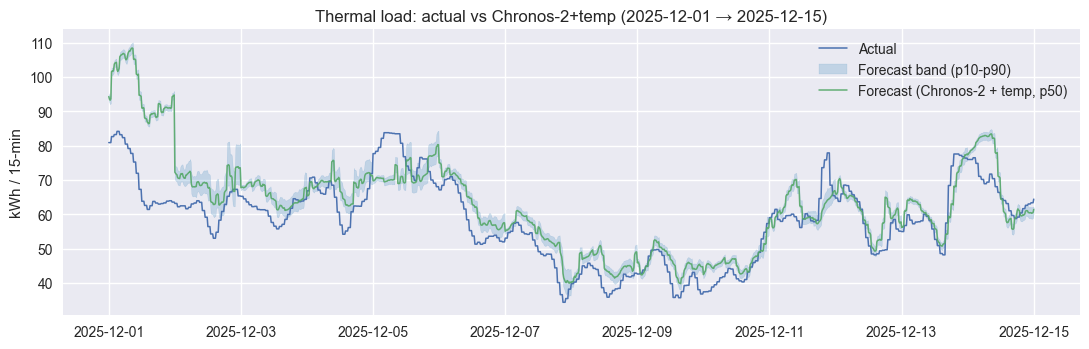

Daily totals: MAE= 295.3990299029454 RMSE= 454.86738746138377


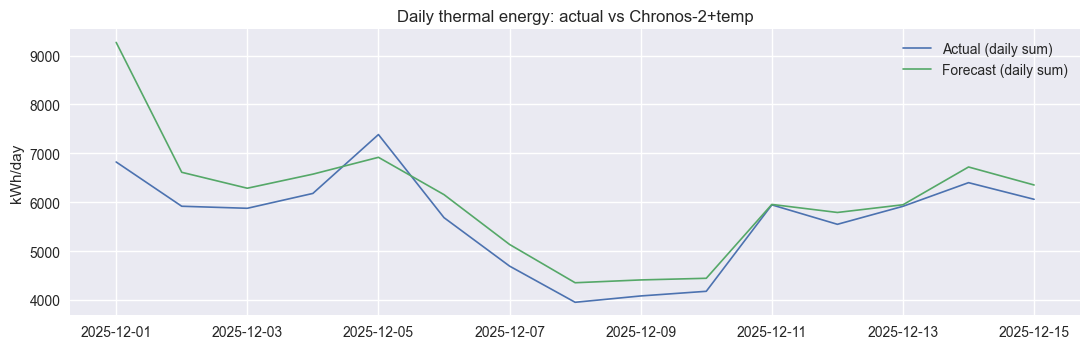

Weekly totals: MAE= 1331.1714634649663 RMSE= 1726.9044766822374


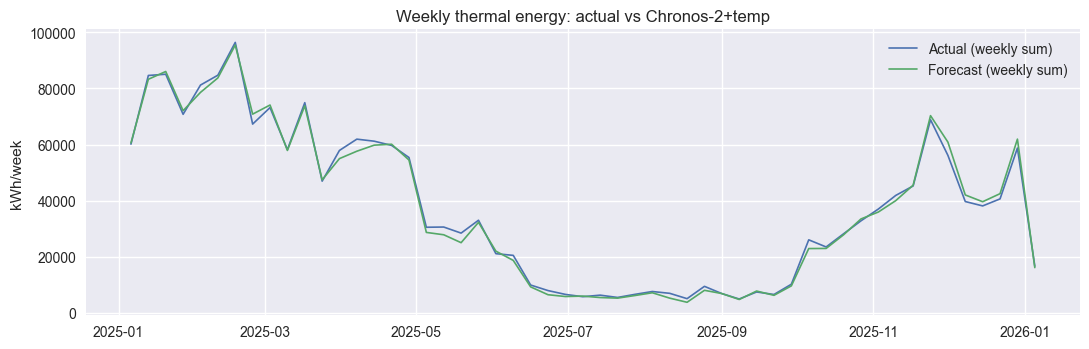

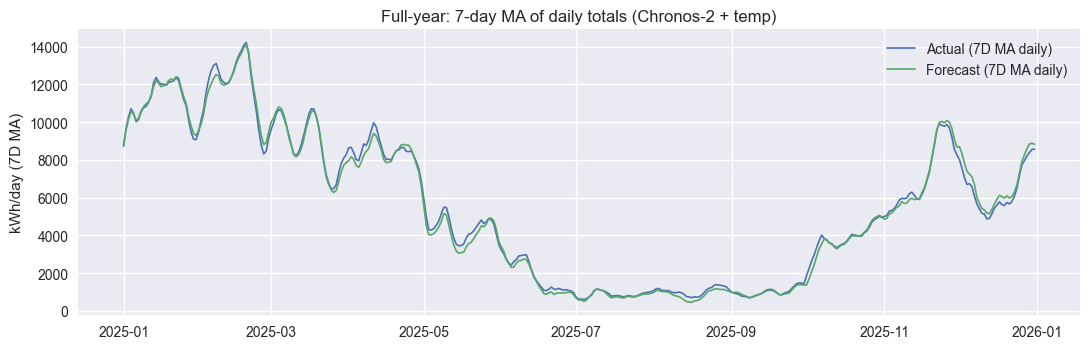

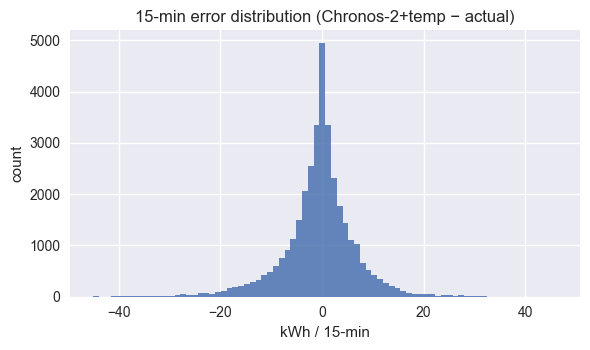

In [5]:
# ----------------------------
# Part 5 – Chronos-2 WITH temperature covariate (daily 96-step forecasts, full-year 35040x1)
# Keeps Part 4 (Chronos-2 univariate) as reference/baseline.
#
# Uses:
#   target: thermal_load history
#   past_covariates["temp"]: outdoor_temperature history (measured)
#   future_covariates["temp"]: temp_forecast_dah for next 96 steps (DAH)
#
# Output: df["thermal_load_forecast_chronos2_temp_p10/p50/p90"]
# ----------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from chronos import Chronos2Pipeline

plt.style.use("seaborn-v0_8")

# === Config ===
MODEL_ID = "amazon/chronos-2"
H = 96
CONTEXT_LEN = 2048

# Plot controls (edit these)
PLOT_START = "2025-12-01"
PLOT_END = "2025-12-15"

# === Inputs expected from Part 1 ===
# df columns: ["timestamp"(tz-aware Europe/Brussels), "thermal_load", "outdoor_temperature", "temp_forecast_dah"]
y = df["thermal_load"].to_numpy(float)
temp_actual = df["outdoor_temperature"].to_numpy(float)
temp_dah = df["temp_forecast_dah"].to_numpy(float)
ts = pd.DatetimeIndex(df["timestamp"])
n = len(df)

num_days = n // 96
assert num_days * 96 == n, f"Expected full days (n multiple of 96), got n={n}"

# === Metrics helpers ===
def _mask(a, b):
    return np.isfinite(a) & np.isfinite(b)

def mae(a, b):
    m = _mask(a, b)
    return float(np.mean(np.abs(a[m] - b[m])))

def rmse(a, b):
    m = _mask(a, b)
    return float(np.sqrt(np.mean((a[m] - b[m]) ** 2)))

# === Load Chronos-2 ===
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

pipe = Chronos2Pipeline.from_pretrained(MODEL_ID, torch_dtype=torch.float32)
if device == "cuda":
    pipe.model = pipe.model.to("cuda")

print("Chronos-2 model_prediction_length =", pipe.model_prediction_length)
print("Chronos-2 quantiles =", pipe.quantiles)

# ----------------------------
# Build full-year 35040x1 forecast, day by day
# ----------------------------
pred_p10 = np.full(n, np.nan)
pred_p50 = np.full(n, np.nan)
pred_p90 = np.full(n, np.nan)

# Day 0 fallback (no history): persistence + small noise
rng = np.random.default_rng(42)
day0 = slice(0, 96)
base0 = float(y[0]) if np.isfinite(y[0]) else float(np.nanmedian(y[np.isfinite(y)]))
std0 = float(np.nanstd(y[day0]))
if not np.isfinite(std0) or std0 == 0:
    std0 = float(np.nanstd(y[np.isfinite(y)]))
day0_pred = base0 + rng.normal(0.0, 0.02 * std0, size=96)
pred_p10[day0] = day0_pred
pred_p50[day0] = day0_pred
pred_p90[day0] = day0_pred

for d in range(1, num_days):
    day_start = d * 96
    day_end = day_start + 96
    day_idx = np.arange(day_start, day_end)

    # Context slices (past only)
    ctx_start = max(0, day_start - CONTEXT_LEN)

    y_ctx = y[ctx_start:day_start]
    t_ctx = temp_actual[ctx_start:day_start]

    # Future temperature covariate for the horizon (known at forecast time)
    t_fut = temp_dah[day_start:day_end]

    # Need finite target + covariates
    ok_ctx = np.isfinite(y_ctx) & np.isfinite(t_ctx)
    y_ctx = y_ctx[ok_ctx]
    t_ctx = t_ctx[ok_ctx]

    if len(y_ctx) < 32 or len(t_ctx) != len(y_ctx) or not np.isfinite(t_fut).all():
        last = float(y[day_start - 1]) if np.isfinite(y[day_start - 1]) else base0
        pred_p10[day_idx] = last
        pred_p50[day_idx] = last
        pred_p90[day_idx] = last
        continue

    # Chronos-2 covariate input format (list of dicts)
    inputs = [
        {
            "target": torch.tensor(y_ctx, dtype=torch.float32),
            "past_covariates": {"temp": torch.tensor(t_ctx, dtype=torch.float32)},
            "future_covariates": {"temp": torch.tensor(t_fut, dtype=torch.float32)},
        }
    ]

    # Returns list[Tensor]; each tensor shaped (n_quantiles, H)
    preds = pipe.predict(inputs=inputs, prediction_length=H, limit_prediction_length=False)
    pred_arr = preds[0].detach().cpu().numpy()

    q_levels = pipe.quantiles
    q10_i = q_levels.index(0.1) if 0.1 in q_levels else 0
    med_i = q_levels.index(0.5) if 0.5 in q_levels else len(q_levels) // 2
    q90_i = q_levels.index(0.9) if 0.9 in q_levels else (len(q_levels) - 1)
    Q = len(q_levels)

    # Expected shapes are typically (batch, Q, H) or (batch, H, Q) or sometimes (Q, H).
    if pred_arr.ndim == 3:
        # remove batch dim
        if pred_arr.shape[0] == 1:
            pred_arr = pred_arr[0]

    if pred_arr.ndim == 2:
        if pred_arr.shape[0] == Q:          # (Q, H)
            y_hat_p10 = pred_arr[q10_i, :]
            y_hat_p50 = pred_arr[med_i, :]
            y_hat_p90 = pred_arr[q90_i, :]
        elif pred_arr.shape[1] == Q:        # (H, Q)
            y_hat_p10 = pred_arr[:, q10_i]
            y_hat_p50 = pred_arr[:, med_i]
            y_hat_p90 = pred_arr[:, q90_i]
        else:
            raise ValueError(f"Unexpected Chronos-2 prediction shape {pred_arr.shape}, Q={Q}")
    else:
        raise ValueError(f"Unexpected Chronos-2 prediction ndim {pred_arr.ndim}, shape {pred_arr.shape}")

    pred_p10[day_idx] = y_hat_p10
    pred_p50[day_idx] = y_hat_p50
    pred_p90[day_idx] = y_hat_p90

df["thermal_load_forecast_chronos2_temp_p10"] = pred_p10
df["thermal_load_forecast_chronos2_temp_p50"] = pred_p50
df["thermal_load_forecast_chronos2_temp_p90"] = pred_p90
pred = pred_p50  # keep downstream metrics on median forecast

# ----------------------------
# Metrics
# ----------------------------
overall_mae = mae(y, pred)
overall_rmse = rmse(y, pred)
bias = float(np.nanmean((pred - y)[_mask(pred, y)]))
print(f"Chronos-2 + temp covariate (15-min, median): MAE={overall_mae:.3f}, RMSE={overall_rmse:.3f}, bias={bias:.3f}")

# ----------------------------
# Plots (same pattern as Parts 3/4)
# ----------------------------
plot_mask = (df["timestamp"] >= pd.Timestamp(PLOT_START, tz="Europe/Brussels")) & (
    df["timestamp"] <= pd.Timestamp(PLOT_END, tz="Europe/Brussels")
)
dff = df.loc[plot_mask].copy()

# 1) 15-min profile
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(dff["timestamp"], dff["thermal_load"], label="Actual", lw=1.1)
ax.fill_between(
    dff["timestamp"],
    dff["thermal_load_forecast_chronos2_temp_p10"],
    dff["thermal_load_forecast_chronos2_temp_p90"],
    color="tab:blue",
    alpha=0.2,
    label="Forecast band (p10-p90)",
)
ax.plot(dff["timestamp"], dff["thermal_load_forecast_chronos2_temp_p50"], label="Forecast (Chronos-2 + temp, p50)", lw=1.1, alpha=0.9)
ax.set_title(f"Thermal load: actual vs Chronos-2+temp ({PLOT_START} → {PLOT_END})")
ax.set_ylabel("kWh / 15-min")
ax.legend()
plt.tight_layout()
plt.show()

# 2) Daily totals
df_day = (
    df.set_index("timestamp")[["thermal_load", "thermal_load_forecast_chronos2_temp_p50"]]
    .resample("D")
    .sum()
)
daily_err = (df_day["thermal_load_forecast_chronos2_temp_p50"] - df_day["thermal_load"]).to_numpy(float)
print("Daily totals: MAE=", float(np.mean(np.abs(daily_err))), "RMSE=", float(np.sqrt(np.mean(daily_err**2))))

fig, ax = plt.subplots(figsize=(11, 3.6))
sl_day = df_day.loc[PLOT_START:PLOT_END]
ax.plot(sl_day.index, sl_day["thermal_load"], label="Actual (daily sum)", lw=1.2)
ax.plot(sl_day.index, sl_day["thermal_load_forecast_chronos2_temp_p50"], label="Forecast (daily sum)", lw=1.2)
ax.set_title("Daily thermal energy: actual vs Chronos-2+temp")
ax.set_ylabel("kWh/day")
ax.legend()
plt.tight_layout()
plt.show()

# 3) Weekly totals
df_wk = (
    df.set_index("timestamp")[["thermal_load", "thermal_load_forecast_chronos2_temp_p50"]]
    .resample("W-MON")
    .sum()
)
wk_err = (df_wk["thermal_load_forecast_chronos2_temp_p50"] - df_wk["thermal_load"]).to_numpy(float)
print("Weekly totals: MAE=", float(np.mean(np.abs(wk_err))), "RMSE=", float(np.sqrt(np.mean(wk_err**2))))

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(df_wk.index, df_wk["thermal_load"], label="Actual (weekly sum)", lw=1.2)
ax.plot(df_wk.index, df_wk["thermal_load_forecast_chronos2_temp_p50"], label="Forecast (weekly sum)", lw=1.2)
ax.set_title("Weekly thermal energy: actual vs Chronos-2+temp")
ax.set_ylabel("kWh/week")
ax.legend()
plt.tight_layout()
plt.show()

# 4) Full-year view (7-day MA of daily totals)
df_day_roll = df_day.rolling(7, min_periods=1).mean()
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(df_day_roll.index, df_day_roll["thermal_load"], label="Actual (7D MA daily)", lw=1.2)
ax.plot(df_day_roll.index, df_day_roll["thermal_load_forecast_chronos2_temp_p50"], label="Forecast (7D MA daily)", lw=1.2)
ax.set_title("Full-year: 7-day MA of daily totals (Chronos-2 + temp)")
ax.set_ylabel("kWh/day (7D MA)")
ax.legend()
plt.tight_layout()
plt.show()

# 5) Error distribution (15-min)
e15 = (df["thermal_load_forecast_chronos2_temp_p50"] - df["thermal_load"]).to_numpy(float)
e15 = e15[np.isfinite(e15)]
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.hist(e15, bins=80, alpha=0.85)
ax.set_title("15-min error distribution (Chronos-2+temp − actual)")
ax.set_xlabel("kWh / 15-min")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

## Comparison

15-min metrics
Ridge MAE= 6.222850670108232 RMSE= 11.147746531200871 bias= -0.49356723627322635
Chronos2 MAE= 7.009678108526857 RMSE= 10.979678620309551 bias= -0.7536416478325271
Chronos2+temp MAE= 4.906995618777683 RMSE= 7.346915723368136 bias= -0.5596790071872301

Daily totals metrics (kWh/day)
Ridge MAE= 411.30415606830775 RMSE= 860.8824515877658 bias= -47.38245468222974
Chronos2 MAE= 506.80490471572847 RMSE= 764.8823097871788 bias= -72.34959819192264
Chronos2+temp MAE= 295.3990299029454 RMSE= 454.86738746138377 bias= -53.72918468997412

Weekly totals metrics (kWh/week)
Ridge MAE= 1161.3042782016298 RMSE= 2388.0698146463164 bias= -326.31313130214846
Chronos2 MAE= 1204.7845979093577 RMSE= 1810.646748671291 bias= -498.25666679342936
Chronos2+temp MAE= 1331.1714634649663 RMSE= 1726.9044766822374 bias= -370.0217436196329


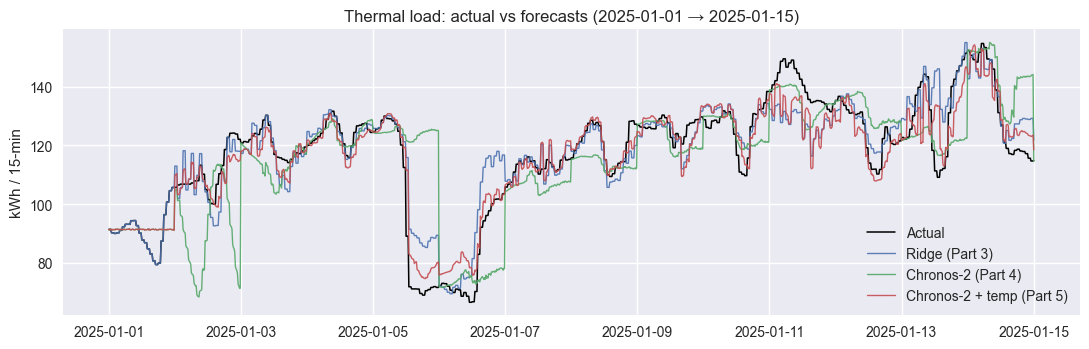

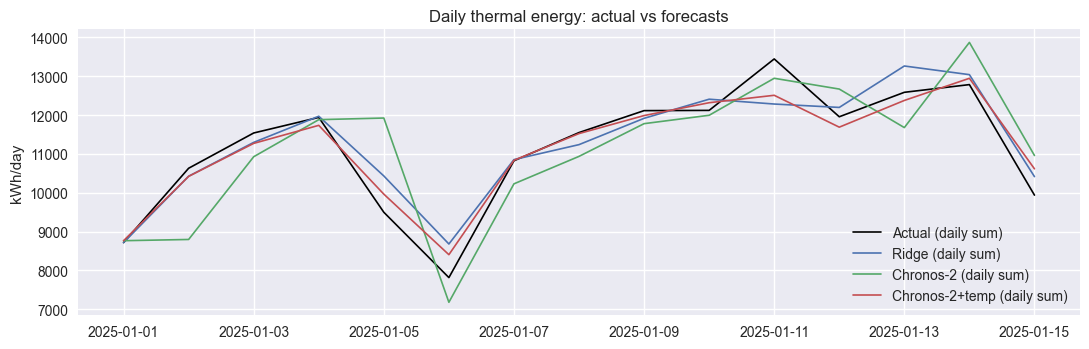

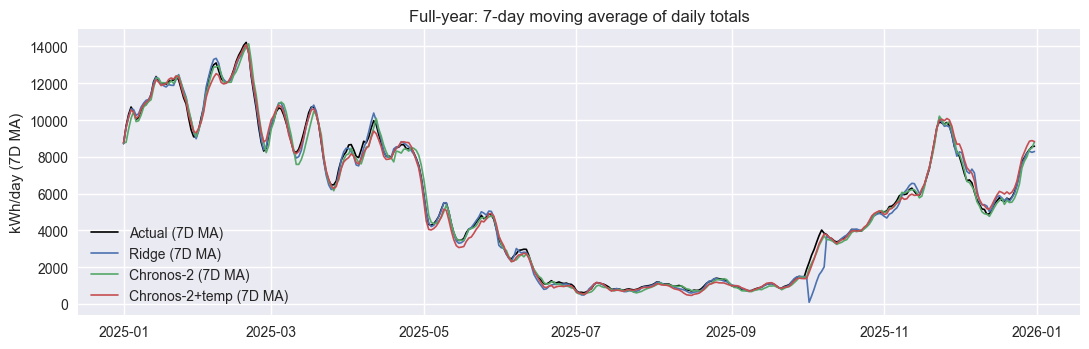

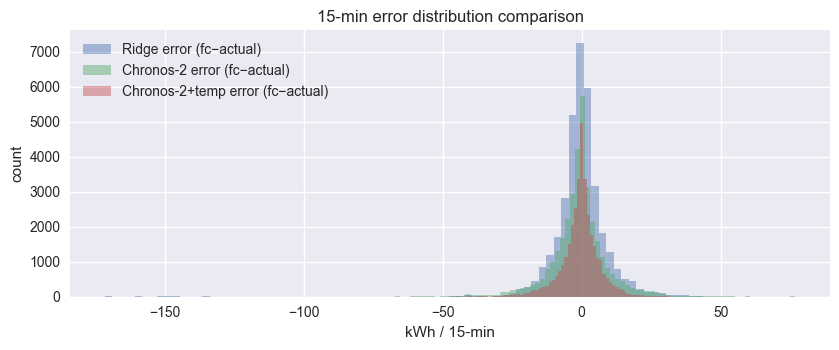

In [6]:
# ----------------------------
# Comparison – Ridge (Part 3) vs Chronos-2 univariate (Part 4) vs Chronos-2 + temp covariate (Part 5)
# Assumes these columns exist in df:
#   - df["thermal_load"]  (actual)
#   - df["thermal_load_forecast_daily_refit_last2days"]   (Part 3 Ridge)
#   - df["thermal_load_forecast_chronos2"]                (Part 4 Chronos-2 univariate)
#   - df["thermal_load_forecast_chronos2_temp_p50"]       (Part 5 Chronos-2 + temperature covariate, median)
# ----------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

# Plot controls (edit these)
PLOT_START = "2025-01-01"
PLOT_END = "2025-01-15"

ACT_COL = "thermal_load"
RIDGE_COL = "thermal_load_forecast_daily_refit_last2days"
C2_COL = "thermal_load_forecast_chronos2"
C2T_COL = "thermal_load_forecast_chronos2_temp_p50"

def _mask(a, b):
    return np.isfinite(a) & np.isfinite(b)

def mae(a, b):
    m = _mask(a, b)
    return float(np.mean(np.abs(a[m] - b[m])))

def rmse(a, b):
    m = _mask(a, b)
    return float(np.sqrt(np.mean((a[m] - b[m]) ** 2)))

def bias(a, b):
    m = _mask(a, b)
    return float(np.mean(b[m] - a[m]))

y = df[ACT_COL].to_numpy(dtype=float)
p_ridge = df[RIDGE_COL].to_numpy(dtype=float)
p_c2 = df[C2_COL].to_numpy(dtype=float)
p_c2t = df[C2T_COL].to_numpy(dtype=float)

# --- 15-min metrics ---
print("15-min metrics")
for name, pred in [("Ridge", p_ridge), ("Chronos2", p_c2), ("Chronos2+temp", p_c2t)]:
    print(name, "MAE=", mae(y, pred), "RMSE=", rmse(y, pred), "bias=", bias(y, pred))

# --- Daily totals metrics ---
df_day = df.set_index("timestamp")[[ACT_COL, RIDGE_COL, C2_COL, C2T_COL]].resample("D").sum()
yd = df_day[ACT_COL].to_numpy(dtype=float)
yd_r = df_day[RIDGE_COL].to_numpy(dtype=float)
yd_c2 = df_day[C2_COL].to_numpy(dtype=float)
yd_c2t = df_day[C2T_COL].to_numpy(dtype=float)

print("\nDaily totals metrics (kWh/day)")
for name, pred in [("Ridge", yd_r), ("Chronos2", yd_c2), ("Chronos2+temp", yd_c2t)]:
    print(name, "MAE=", mae(yd, pred), "RMSE=", rmse(yd, pred), "bias=", bias(yd, pred))

# --- Weekly totals metrics ---
df_wk = df.set_index("timestamp")[[ACT_COL, RIDGE_COL, C2_COL, C2T_COL]].resample("W-MON").sum()
yw = df_wk[ACT_COL].to_numpy(dtype=float)
yw_r = df_wk[RIDGE_COL].to_numpy(dtype=float)
yw_c2 = df_wk[C2_COL].to_numpy(dtype=float)
yw_c2t = df_wk[C2T_COL].to_numpy(dtype=float)

print("\nWeekly totals metrics (kWh/week)")
for name, pred in [("Ridge", yw_r), ("Chronos2", yw_c2), ("Chronos2+temp", yw_c2t)]:
    print(name, "MAE=", mae(yw, pred), "RMSE=", rmse(yw, pred), "bias=", bias(yw, pred))

# ----------------------------
# Plots
# ----------------------------
plot_mask = (df["timestamp"] >= pd.Timestamp(PLOT_START, tz="Europe/Brussels")) & (
    df["timestamp"] <= pd.Timestamp(PLOT_END, tz="Europe/Brussels")
)
dff = df.loc[plot_mask].copy()

# 1) 15-min time series overlay
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(dff["timestamp"], dff[ACT_COL], label="Actual", lw=1.1, color="black")
ax.plot(dff["timestamp"], dff[RIDGE_COL], label="Ridge (Part 3)", lw=1.0, alpha=0.9)
ax.plot(dff["timestamp"], dff[C2_COL], label="Chronos-2 (Part 4)", lw=1.0, alpha=0.9)
ax.plot(dff["timestamp"], dff[C2T_COL], label="Chronos-2 + temp (Part 5)", lw=1.0, alpha=0.9)
ax.set_title(f"Thermal load: actual vs forecasts ({PLOT_START} → {PLOT_END})")
ax.set_ylabel("kWh / 15-min")
ax.legend()
plt.tight_layout()
plt.show()

# 2) Daily totals overlay (same date range)
sl_day = df_day.loc[PLOT_START:PLOT_END]
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(sl_day.index, sl_day[ACT_COL], label="Actual (daily sum)", lw=1.2, color="black")
ax.plot(sl_day.index, sl_day[RIDGE_COL], label="Ridge (daily sum)", lw=1.2)
ax.plot(sl_day.index, sl_day[C2_COL], label="Chronos-2 (daily sum)", lw=1.2)
ax.plot(sl_day.index, sl_day[C2T_COL], label="Chronos-2+temp (daily sum)", lw=1.2)
ax.set_title("Daily thermal energy: actual vs forecasts")
ax.set_ylabel("kWh/day")
ax.legend()
plt.tight_layout()
plt.show()

# 3) Full-year daily 7D moving average
df_day_roll = df_day.rolling(7, min_periods=1).mean()
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(df_day_roll.index, df_day_roll[ACT_COL], label="Actual (7D MA)", lw=1.2, color="black")
ax.plot(df_day_roll.index, df_day_roll[RIDGE_COL], label="Ridge (7D MA)", lw=1.2)
ax.plot(df_day_roll.index, df_day_roll[C2_COL], label="Chronos-2 (7D MA)", lw=1.2)
ax.plot(df_day_roll.index, df_day_roll[C2T_COL], label="Chronos-2+temp (7D MA)", lw=1.2)
ax.set_title("Full-year: 7-day moving average of daily totals")
ax.set_ylabel("kWh/day (7D MA)")
ax.legend()
plt.tight_layout()
plt.show()

# 4) Error histograms (15-min)
e_r = (df[RIDGE_COL] - df[ACT_COL]).to_numpy(dtype=float)
e_c2 = (df[C2_COL] - df[ACT_COL]).to_numpy(dtype=float)
e_c2t = (df[C2T_COL] - df[ACT_COL]).to_numpy(dtype=float)

e_r = e_r[np.isfinite(e_r)]
e_c2 = e_c2[np.isfinite(e_c2)]
e_c2t = e_c2t[np.isfinite(e_c2t)]

fig, ax = plt.subplots(figsize=(8.5, 3.6))
ax.hist(e_r, bins=80, alpha=0.45, label="Ridge error (fc−actual)")
ax.hist(e_c2, bins=80, alpha=0.45, label="Chronos-2 error (fc−actual)")
ax.hist(e_c2t, bins=80, alpha=0.45, label="Chronos-2+temp error (fc−actual)")
ax.set_title("15-min error distribution comparison")
ax.set_xlabel("kWh / 15-min")
ax.set_ylabel("count")
ax.legend()
plt.tight_layout()
plt.show()

## Export

In [7]:
# ----------------------------
# Export – thermal load forecasts (same style as output/forecast/forecast_ev_rolling_horizon.csv)
# Creates: output/forecast/forecast_thermal_load_rolling_horizon.csv
#
# Strategy selection:
#   - "a"  -> Ridge (Part 3) daily refit last 2 days
#   - "c2" -> Chronos-2 univariate (Part 4)
#   - "c2t"-> Chronos-2 + temperature covariate (Part 5)
#
# Columns written:
#   timestamp, forecast_thermal_a, forecast_thermal_c2, forecast_thermal_c2t_p10, forecast_thermal_c2t_p50, forecast_thermal_c2t_p90
# ----------------------------

from pathlib import Path
import pandas as pd
import numpy as np

OUTPUT_DIR = Path("../output/forecast")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
EXPORT_PATH = OUTPUT_DIR / "forecast_thermal_load_rolling_horizon.csv"

# Must exist from Parts 3/4/5
COL_A = "thermal_load_forecast_daily_refit_last2days"
COL_C2 = "thermal_load_forecast_chronos2"
COL_C2T_P10 = "thermal_load_forecast_chronos2_temp_p10"
COL_C2T_P50 = "thermal_load_forecast_chronos2_temp_p50"
COL_C2T_P90 = "thermal_load_forecast_chronos2_temp_p90"

forecast_cols = [COL_A, COL_C2, COL_C2T_P10, COL_C2T_P50, COL_C2T_P90]
for c in forecast_cols:
    if c not in df.columns:
        raise ValueError(f"Missing column {c!r}. Run the corresponding part first.")

# --- Post-processing: thermal load cannot be negative ---
# Set negative forecasts to 0 for ALL methods.
for c in forecast_cols:
    s = pd.to_numeric(df[c], errors="coerce").astype(float)
    n_neg = int((s < 0).sum())
    if n_neg:
        print(f"Clipping {n_neg} negative values in {c} to 0.")
    df[c] = s.clip(lower=0.0)

# Timestamp formatting consistent with existing forecast CSVs in output/forecast
ts_out = pd.DatetimeIndex(df["timestamp"]).map(lambda t: t.strftime("%Y-%m-%d %H:%M:%S%z"))
# insert colon in timezone offset (+0100 -> +01:00) to match your files
ts_out = ts_out.str.slice(0, 19) + ts_out.str.slice(19, 22) + ":" + ts_out.str.slice(22, 24)

export_df = pd.DataFrame(
    {
        "timestamp": ts_out,
        "forecast_thermal_a": pd.to_numeric(df[COL_A], errors="coerce").astype(float).values,
        "forecast_thermal_c2": pd.to_numeric(df[COL_C2], errors="coerce").astype(float).values,
        "forecast_thermal_c2t_p10": pd.to_numeric(df[COL_C2T_P10], errors="coerce").astype(float).values,
        "forecast_thermal_c2t_p50": pd.to_numeric(df[COL_C2T_P50], errors="coerce").astype(float).values,
        "forecast_thermal_c2t_p90": pd.to_numeric(df[COL_C2T_P90], errors="coerce").astype(float).values,
    }
)

export_df.to_csv(EXPORT_PATH, index=False)
print(f"Exported {len(export_df)} rows to {EXPORT_PATH}")

# --- Optional: choose which strategy you want MPC to use ---
THERMAL_STRATEGY = "c2t_p50"  # "a", "c2", "c2t_p10", "c2t_p50", or "c2t_p90"
col_map = {
    "a": "forecast_thermal_a",
    "c2": "forecast_thermal_c2",
    "c2t_p10": "forecast_thermal_c2t_p10",
    "c2t_p50": "forecast_thermal_c2t_p50",
    "c2t_p90": "forecast_thermal_c2t_p90",
}
chosen_col = col_map[THERMAL_STRATEGY]
thermal_forecast_series = export_df[chosen_col].to_numpy(dtype=float)
print("Selected thermal strategy:", THERMAL_STRATEGY, "->", chosen_col)

Clipping 1692 negative values in thermal_load_forecast_daily_refit_last2days to 0.
Clipping 16 negative values in thermal_load_forecast_chronos2 to 0.
Clipping 1552 negative values in thermal_load_forecast_chronos2_temp_p10 to 0.
Clipping 247 negative values in thermal_load_forecast_chronos2_temp_p50 to 0.
Clipping 22 negative values in thermal_load_forecast_chronos2_temp_p90 to 0.
Exported 35040 rows to ..\output\forecast\forecast_thermal_load_rolling_horizon.csv
Selected thermal strategy: c2t_p50 -> forecast_thermal_c2t_p50
